# BPT diagram
To separate these different classes of galaxies on a BPT diagram plotting **[O III]$\lambda5007$/H$\beta$** versus **[N II]$\lambda6583$/H$\alpha$**, you can use a combination of theoretical and empirical demarcation lines. 

For the formulas below, let:
*   $y = \log([\text{O III}] / \text{H}\beta)$
*   $x = \log([\text{N II}] / \text{H}\alpha)$

**1. Pure Star-Forming Galaxies**
Galaxies powered purely by star formation fall below the empirical boundary defined by Kauffmann et al. (2003).
**Formula:** $y < \frac{0.61}{x - 0.05} + 1.30$

**2. Composite (Transition) Galaxies**
These objects have spectra indicating a blend of star formation and AGN activity. They fall between the Kauffmann (2003) empirical line and the theoretical maximum starburst line defined by Kewley et al. (2001).
**Formula:** $\frac{0.61}{x - 0.05} + 1.30 < y < \frac{0.61}{x - 0.47} + 1.19$

**3. Active Galactic Nuclei (AGN)**
Galaxies that are entirely dominated by an AGN (which includes both Seyferts and LINERs) fall above the Kewley (2001) theoretical maximum starburst line. These objects cannot be explained by any combination of star formation parameters.
**Formula:** $y > \frac{0.61}{x - 0.47} + 1.19$

**4. Separating Seyferts from LINERs**
Within the AGN regime (above the Kewley 2001 line), objects are further split based on their ionization state. While the [S II] and [O I] diagrams are often preferred for this separation, an empirical dividing line specific to the [N II]/H$\alpha$ diagram was defined by Schawinski et al. (2007).
**Demarcation Line Formula:** $y = 1.05x + 0.45$
*   **Seyfert galaxies** have higher ionization ratios and fall **above** this line ($y > 1.05x + 0.45$).
*   **LINER galaxies** have lower ionization ratios and fall **below** this line ($y < 1.05x + 0.45$).

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sdss.metadata import MetaData

meta = MetaData()
pd.set_option("display.max_columns", None)

# Custom functions

## bpt boundaries

In [4]:
def bpt_boundary_lines():
    # Kauffmann et al. (2003) - Empirical Star-Forming line
    x_kauff = np.linspace(-2.0, 0.0, 1000)
    y_kauff = 0.61 / (x_kauff - 0.05) + 1.3

    # Kewley et al. (2001) - Theoretical Maximum Starburst line
    x_kewley = np.linspace(-2.0, 0.4, 1000)
    y_kewley = 0.61 / (x_kewley - 0.47) + 1.19

    # Schawinski et al. (2007) - Seyfert / LINER division
    x_schaw = np.linspace(-0.18, 1.5, 1000)
    y_schaw = 1.05 * x_schaw + 0.45

    return (x_kauff, y_kauff), (x_kewley, y_kewley), (x_schaw, y_schaw)

## BPT figure

In [5]:
def plot_bpt(n2_ha, o3_hb, fig, ax):
    """
    Plots a standard [N II] BPT diagram.

    Parameters:
    n2_ha : array-like
        log10([N II] 6584 / H_alpha)
    o3_hb : array-like
        log10([O III] 5007 / H_beta)
    """
    # -------------------------------------------------------------
    # 1. Plot the Demarcation Lines
    # -------------------------------------------------------------
    (x_kauff, y_kauff), (x_kewley, y_kewley), (x_schaw, y_schaw) = bpt_boundary_lines()

    ax.plot(x_kauff, y_kauff, "k--", lw=2, label="Kauffmann+03 (SF/Composite)")

    ax.plot(x_kewley, y_kewley, "k-", lw=2, label="Kewley+01 (Composite/AGN)")

    ax.plot(x_schaw, y_schaw, "k-.", lw=2, label="Schawinski+07 (Seyfert/LINER)")

    # -------------------------------------------------------------
    # 2. Plot the Data
    # -------------------------------------------------------------
    ax.scatter(n2_ha, o3_hb, color="red")
    # -------------------------------------------------------------
    # 3. Formatting
    # -------------------------------------------------------------
    # Add region text labels
    ax.text(-1.0, -0.5, "Star Forming", fontsize=14, ha="center")
    ax.text(-0.15, -0.5, "Composite", fontsize=14, ha="center", rotation=-70)
    ax.text(-0.5, 1.25, "Seyfert", fontsize=14, ha="center")
    ax.text(0.5, -0.5, "LINER", fontsize=14, ha="center")

    # Set axis limits and labels
    ax.set_xlim([-1.5, 1.0])
    ax.set_ylim([-1.5, 1.5])
    ax.set_xlabel(r"$\log_{10}([\mathrm{N~II}] / \mathrm{H}\alpha)$", fontsize=14)
    ax.set_ylabel(r"$\log_{10}([\mathrm{O~III}] / \mathrm{H}\beta)$", fontsize=14)
    ax.tick_params(labelsize=12)

    ax.legend(loc="lower left", fontsize=8, frameon=False)

    return fig, ax

# Config

## Constants

In [6]:
se_cols = ["mse", "mse_filter_250", "mse_97", "mse_filter_250_97"]
se_rank_cols = [f"rank_{col}" for col in se_cols]
# ----------------------------------------------
rse_cols = [f"{col}_rel" for col in se_cols]
rse_rank_cols = [f"rank_{col}_rel" for col in se_cols]
# ----------------------------------------------
se_family = ["mse", "mse_97", "mse_filter_250", "mse_filter_250_97"]
rse_family = [f"{col}_rel" for col in se_family]

In [12]:
cols_ratios = [
    "balmer_decrement",
    "nii_to_halpha",
    "oiii_to_hbeta",
    "oiii_to_oii",
    "o3n2_index",
    "sii_to_halpha",
    "sii_density_ratio",
]

## Directories

In [7]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
ch_4_dir = f"{thesis_dir}/chapters/04_figures"

# Data

In [ ]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave * 0.1

spectra = np.load(f"{spectra_dir}/spectra_imputed.npy", mmap_mode="r")

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

meta_with_ratios_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop_with_ratios.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(f"{spectra_dir}/ids_imputing.npy", mmap_mode="r")

# lines_df = pd.read_csv(
#     f"{spectra_dir}/meta_data/lines_EdgarOrtiz.csv",
#     index_col="specObjID",
# )

# meta_with_lines_df = pd.read_csv(
#     f"{spectra_dir}/final_spec_n_z_warning_drop_with_lines.csv.gz",
#     index_col="specobjid",
# )

In [9]:
meta_with_ratios_df.head(3)
# final_meta_df.head(3)

,mjd,plate,fiberid,run2d,ra,dec,z,zErr,zWarning,class,subClass,z_noqso,zErr_noqso,zWarning_noqso,targetType,programname,instrument,snMedian,ABSSB,BROAD,ebv,indexArray,oii_3726_flux,oii_3729_flux,h_beta_flux,oiii_4959_flux,oiii_5007_flux,oiii_flux,h_alpha_flux,nii_6548_flux,nii_6584_flux,sii_6717_flux,sii_6731_flux,oii_3726_flux_err,oii_3729_flux_err,h_beta_flux_err,oiii_4959_flux_err,oiii_5007_flux_err,oiii_flux_err,h_alpha_flux_err,nii_6548_flux_err,nii_6584_flux_err,sii_6717_flux_err,sii_6731_flux_err,balmer_decrement,nii_to_halpha,oiii_to_hbeta,oiii_to_oii,o3n2_index,sii_to_halpha,sii_density_ratio
specobjid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1874756710606858240,52976,1665,485,26,49.861444,41.540485,0.017909,0.000004,0,GALAXY,BROADLINE,0,0,0,SCIENCE,perseus,SDSS,94.13022,BROADLINE,BROADLINE,0.138756,2.0,NaN,30418890.00,109.63340,NaN,176.81650,174.70850,109.7575,49.30014,148.70060,3.150983,NaN,-7.832294e-01,1.842604e+06,17.43791,19.09110,17.88523,21.45677,35.74986,11.300770,34.08569,31.61602,31.82735,1.001132,1.354810,1.612798,NaN,0.075701,NaN,NaN
1874765781577787392,52976,1665,518,26,49.918970,41.548643,0.021434,0.000004,0,GALAXY,BROADLINE,0,0,0,SCIENCE,perseus,SDSS,92.63803,BROADLINE,BROADLINE,0.141073,3.0,NaN,30924.64,41.71867,2.058654,72.43165,67.69716,132.8577,29.28021,88.31586,NaN,18.97761,1.139662e+06,3.962919e+04,14.98429,12.20163,12.41198,12.80094,23.17760,6.114465,18.44262,16.03369,16.29948,3.184610,0.664740,1.736193,NaN,0.416946,NaN,NaN
1874776226938251264,52976,1665,556,26,50.251707,41.562451,0.015699,0.000006,0,GALAXY,BROADLINE,0,0,0,SCIENCE,perseus,SDSS,90.91905,BROADLINE,BROADLINE,0.142785,5.0,NaN,NaN,169.26810,NaN,147.23940,150.70450,261.2984,45.43762,137.05040,27.470890,NaN,-7.819291e-01,-7.819291e-01,14.49883,15.25546,15.11998,14.26691,25.16728,7.907939,23.85214,23.79437,23.95586,1.543695,0.524498,0.869859,NaN,0.219705,NaN,NaN


# Scores

## SE + RSE scores

In [10]:
bin_id = "bin_03"
res_scores_03_df = pd.read_csv(
    f"{scores_dir}/{bin_id}/scores_{bin_id}.csv.gz",
    usecols=["specobjid"] + se_cols + rse_cols,
    index_col="specobjid",
)

rank = np.arange(res_scores_03_df.shape[0]) + 1
res_03_scores_rank_df = res_scores_03_df.copy()
# score_rank_df
for col in res_scores_03_df.columns:

    index_sorted = res_scores_03_df.sort_values(by=col, ascending=False).index

    res_03_scores_rank_df.loc[index_sorted, f"rank_{col}"] = rank
    res_03_scores_rank_df[f"rank_{col}"].astype(int)

n_spec = res_scores_03_df.shape[0]
n_top_1_pct = int(n_spec * 0.01)
n_top_1_pct, n_spec

(1818, 181850)

In [11]:
res_03_scores_rank_df.head()

,mse_rel,mse_filter_250_97_rel,mse_97_rel,mse,mse_97,mse_filter_250_97,mse_filter_250,mse_filter_250_rel,rank_mse_rel,rank_mse_filter_250_97_rel,rank_mse_97_rel,rank_mse,rank_mse_97,rank_mse_filter_250_97,rank_mse_filter_250,rank_mse_filter_250_rel
specobjid,,,,,,,,,,,,,,,,
1437819582281705472,3.549991,2.582845,2.660625,3.570211,2.631072,2.548220,3.305904,3.388511,13249.0,21423.0,20366.0,8755.0,10313.0,10084.0,7623.0,15236.0
1792473383787587584,3.592197,2.827291,2.874075,3.230481,2.715585,2.662638,3.150359,3.490994,11806.0,6400.0,7507.0,16243.0,7376.0,6116.0,11194.0,11277.0
1566270578824865792,3.799695,2.967733,3.016445,3.215022,2.564632,2.517923,3.124369,3.686568,6946.0,3265.0,3952.0,16789.0,13498.0,11560.0,11972.0,6498.0
1833056640966879232,3.418285,2.751345,2.802071,2.965650,2.507619,2.460364,2.933262,3.354621,18889.0,9324.0,10444.0,28087.0,16967.0,14928.0,20074.0,16849.0
2824940385879484416,3.393606,2.592578,2.649388,2.839407,2.384083,2.344867,2.787019,3.352981,20228.0,20498.0,21431.0,36848.0,27263.0,24506.0,29881.0,16922.0


In [13]:
col
# Compute percentiles (45th to 55th percentiles) for each column
percentiles = np.arange(0.45, 0.55, 0.05)
# Create a DataFrame of percentiles for each column in fluxes_df[lines_cols]
ratios_percentiles_df = meta_with_ratios_df[cols_ratios].quantile(q=percentiles).T
# Optionally rename the rows as "10th", "20th", etc.
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
# Display the result
ratios_percentiles_df

,45th,50th,55th
balmer_decrement,3.768733,3.914880,4.063091
nii_to_halpha,0.420978,0.456375,0.499100
oiii_to_hbeta,0.643393,0.743624,0.861812
oiii_to_oii,0.677151,0.735276,0.802389
o3n2_index,0.087218,0.134590,0.184831
sii_to_halpha,0.342261,0.359278,0.378422
sii_density_ratio,1.369007,1.400479,1.432541


# Residual Common anomalies

In [14]:
overview_common_dict = {
    # row 1
    "narrow_line": 734111514142730240,
    "broad_line_large_OIII": 1633733043925575680,
    # row 2
    "broad_emission_dips_OIII_half": 1192355533059811328,
    "star_forming_step_blue_slope": 1959124163192973312,
    # row 3
    "blue_bump_emission": 531492683672217600,
    "passive_star": 1780176998165932032,
    # row 4
    "spike": 1413149843194406912,
    "noise_forest": 637325355518027776,
}

In [15]:
meta_with_ratios_df.loc[734111514142730240, cols_ratios]
# balmer_decrement      3.29336
# nii_to_halpha         0.05016
# oiii_to_hbeta        3.990424
# oiii_to_oii               NaN
# o3n2_index           1.900664
# sii_to_halpha        0.163502
# sii_density_ratio    1.362553

balmer_decrement      3.29336
nii_to_halpha         0.05016
oiii_to_hbeta        3.990424
oiii_to_oii               NaN
o3n2_index           1.900664
sii_to_halpha        0.163502
sii_density_ratio    1.362553
Name: 734111514142730240, dtype: object

In [16]:
ratios_dict = {
    "specobjid": [],
    "name": [],
    "balmer_decrement": [],
    "nii_to_halpha": [],
    "oiii_to_hbeta": [],
    "oiii_to_oii": [],
    "o3n2_index": [],
    "sii_to_halpha": [],
    "sii_density_ratio": [],
}


for title, specid in overview_common_dict.items():
    ratios_dict["name"].append(title)
    ratios_dict["specobjid"].append(specid)
    for col in cols_ratios:
        try:
            ratios_dict[col].append(meta_with_ratios_df.loc[specid, col])
        except KeyError:
            ratios_dict[col].append(np.nan)

In [17]:
common_anomalies_ratios_df = pd.DataFrame(ratios_dict)
common_anomalies_ratios_df.to_clipboard()
common_anomalies_ratios_df

,specobjid,name,balmer_decrement,nii_to_halpha,oiii_to_hbeta,oiii_to_oii,o3n2_index,sii_to_halpha,sii_density_ratio
0,734111514142730240,narrow_line,3.293360,0.050160,3.990424,NaN,1.900664,0.163502,1.362553
1,1633733043925575680,broad_line_large_OIII,3.891876,0.204359,10.550430,11.752099,1.712876,0.217171,1.109206
2,1192355533059811328,broad_emission_dips_OIII_half,5.013954,0.599002,8.754367,7.460670,1.164797,0.344767,1.184883
3,1959124163192973312,star_forming_step_blue_slope,3.437888,0.182478,1.409797,0.595381,0.887945,0.278217,1.376201
4,531492683672217600,blue_bump_emission,3.584317,0.371369,0.517071,0.429446,0.143744,0.333807,1.389607
5,1780176998165932032,passive_star,NaN,NaN,NaN,0.123804,NaN,NaN,NaN
6,1413149843194406912,spike,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,637325355518027776,noise_forest,5.763929,0.055846,0.861052,0.411711,1.188040,NaN,NaN


In [18]:
class_common_anomalies_dict = {
    "specobjid": [],
    "name": [],
    "class": [],
}

for title, specid in overview_common_dict.items():

    class_common_anomalies_dict["name"].append(title)
    class_common_anomalies_dict["specobjid"].append(specid)
    try:
        class_ = final_meta_df.loc[specid, "subClass"]
        class_common_anomalies_dict["class"].append(class_)
    except KeyError:
        class_common_anomalies_dict["class"].append(np.nan)

class_common_anomalies_df = pd.DataFrame(class_common_anomalies_dict)
class_common_anomalies_df.to_clipboard()
class_common_anomalies_df

,specobjid,name,class
0,734111514142730240,narrow_line,STARBURST
1,1633733043925575680,broad_line_large_OIII,STARBURST
2,1192355533059811328,broad_emission_dips_OIII_half,AGN BROADLINE
3,1959124163192973312,star_forming_step_blue_slope,STARBURST
4,531492683672217600,blue_bump_emission,STARFORMING
5,1780176998165932032,passive_star,NaN
6,1413149843194406912,spike,NaN
7,637325355518027776,noise_forest,NaN


## BPT

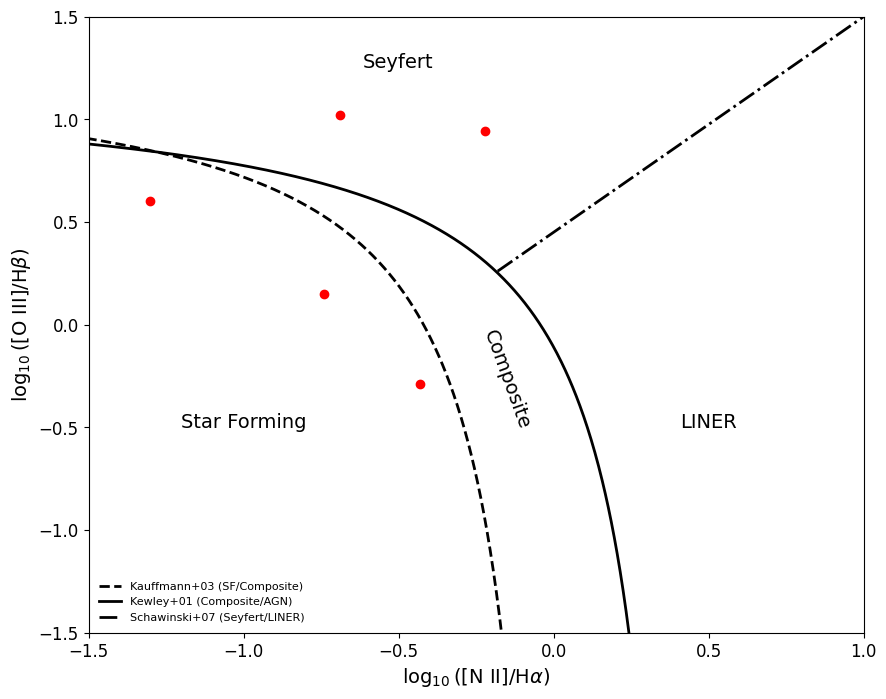

In [21]:
fig, ax = plt.subplots(figsize=(10, 8))

n2_ha = [0.050, 0.204, 0.599, 0.182, 0.371]
o3_hb = [3.990, 10.550, 8.754, 1.410, 0.517]
log_n2_ha = np.log10(n2_ha)
log_o3_hb = np.log10(o3_hb)

fig, ax = plot_bpt(log_n2_ha, log_o3_hb, fig, ax)